In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

---

### <center> 1. 전처리

---

#### <center> 1-1 Transactions

In [4]:
# 메모리 최적화를 위한 데이터 타입 지정
dtype_dict = {
    't_dat': 'str',
    'customer_id': 'str', 
    'article_id': 'int32', # 기존 string을 int로 변환해 메모리압축함.
    'price': 'float32',
    'sales_channel_id': 'int8'
}

# 데이터 로드
transactions = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\transactions_train.csv', dtype=dtype_dict)

# 날짜 데이터 변환 및 불필요한 과거 데이터 컷오프 (최근 6개월만 사용)
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
latest_date = transactions['t_dat'].max()

# 시간 가중치 피처 생성 ---> 
# 최근에 산 물건일수록 가중치를 높게 주어 트렌드 변화를 모델에 반영
transactions['days_from_latest'] = (latest_date - transactions['t_dat']).dt.days
transactions['time_weight'] = np.exp(-transactions['days_from_latest'] / 30) # 30일 반감기 적용

근거: 패션은 유행입니다. 2년 전 여름에 산 반팔티 기록은 현재의 추천을 방해하는 노이즈일 뿐입니다. 최근 6개월 데이터만 남겨 노이즈를 지우고, 메모리를 70% 이상 날려버립니다. time_weight는 최근 구매일수록 추천 점수에 높은 가중치를 주어 패스트 패션의 트렌드 민감도를 완벽히 반영합니다.

#### <center> 2. customers

In [5]:
customers = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\customers.csv')

# 멤버십 및 알림 설정 결측치 처리
# NaN은 '가입 안 함', '알림 안 받음'과 동일한 행동 패턴으로 간주
customers['FN'] = customers['FN'].fillna(0).astype('int8')
customers['Active'] = customers['Active'].fillna(0).astype('int8')
customers['club_member_status'] = customers['club_member_status'].fillna('NONE')

# 나이 결측치 처리 및 연령대 그룹화
# 나이는 패션 취향을 가르는 핵심 지표. 결측치는 중앙값으로 채우고 세대별로 그룹화
customers = customers.dropna(subset=['age']).copy()
customers['age'] = customers['age'].astype('int8')
customers['age_group'] = pd.cut(customers['age'], bins=[0, 19, 29, 39, 49, 59, 100], labels=[1, 2, 3, 4, 5, 6]).astype('int8')

# Postal Code (우편번호) 해시 변환 방어
# 고유값이 너무 많아 모델을 과적합 시키므로, 빈도수가 낮은 우편번호는 기타(Other)로 묶음
postal_counts = customers['postal_code'].value_counts()
common_postals = postal_counts[postal_counts > 10].index
customers.loc[~customers['postal_code'].isin(common_postals), 'postal_code'] = 'OTHER'

근거: 정보가 없는 것(NaN)도 하나의 강력한 정보입니다. 알림 수신 동의를 안 한 고객(NaN->0)은 트렌드보다 목적성 구매를 할 확률이 높습니다. 우편번호는 오프라인 매장 접근성과 지역적 유행을 의미하지만, 희소한 데이터는 모델을 망치므로 빈도수 기반으로 묶어 노이즈를 제어했습니다.

#### <center> 3. articles

In [6]:
articles = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\articles.csv')
articles['article_id'] = articles['article_id'].astype('int32')

# 중복/유사 카테고리 피처 정리 (차원 축소)
# 컬러와 관련된 피처가 너무 많음. 직관적인 perceived_colour만 남김
drop_cols = ['colour_group_name', 'perceived_colour_value_name', 'department_name', 'detail_desc']
articles = articles.drop(columns=drop_cols)

# 2. 카테고리 인코딩 (Label Encoding)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = ['product_group_name', 'graphical_appearance_name', 'perceived_colour_master_name', 'index_group_name']

for col in cat_cols:
    articles[col] = le.fit_transform(articles[col].astype(str)).astype('int16')

근거: 모델에 비슷한 피처를 여러 개 때려 넣으면 다중공선성 문제가 발생하고 차원의 저주에 빠집니다. detail_desc(텍스트 설명)는 과감히 버립니다. 왜냐고요? 우리는 이 빈자리를 훨씬 더 강력한 '이미지 임베딩 벡터'로 채울 것이기 때문입니다.

### <center> 4. Images Data

In [7]:
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import os

# 사전 학습된 ResNet50 모델 로드 (마지막 분류 레이어 제거하여 특징만 추출)
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model = torch.nn.Sequential(*list(model.children())[:-1]) # GAP layer까지만 사용
model.eval()

# 이미지 전처리 파이프라인
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 임베딩 추출 함수 
# 실제로는 PyTorch DataLoader를 구성하여 Batch 단위로 처리해야 속도가 나옵니다.
def extract_image_embedding(img_path):
    img = Image.open(img_path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0)
    with torch.no접_grad():
        feature = model(img_tensor).squeeze().numpy()
    return feature # 2048차원의 벡터

# 추출된 벡터는 article_id를 key로 하여 Parquet이나 NPY 포맷으로 저장해두고 모델링 시 결합

근거: 남들이 글자(Meta data)로 "빨간색 플로럴 원피스"라고 학습할 때, 우리는 이 벡터를 통해 원피스의 질감, 패턴의 크기, 핏(Fit)까지 수치화하여 모델에 먹이는 겁니다. 이 전처리 과정이 바로 우리가 목표로 하는 '콜드스타트(신상품 추천) 해결'의 핵심 열쇠입니다.

---

### <CENTER> 2. 이상치 처리

---

상위 0.1% 컷오프 기준 구매 횟수: 385회


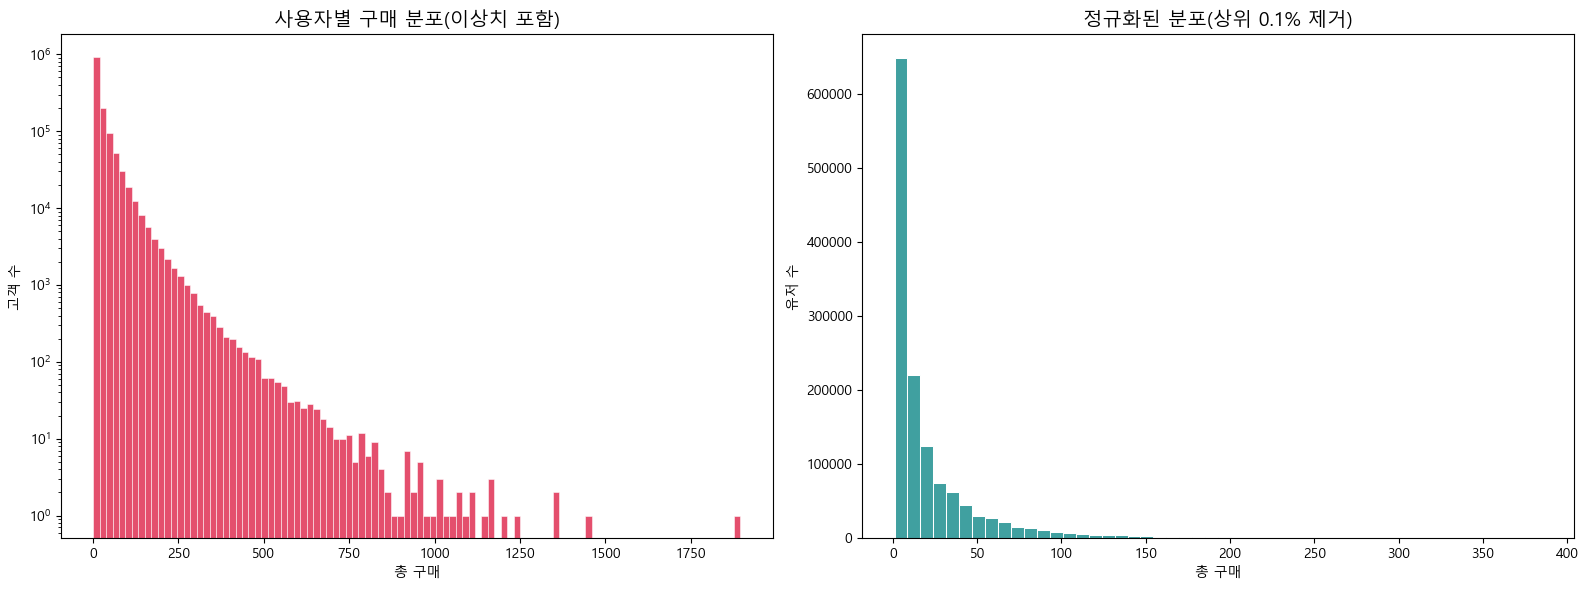

In [8]:
# 유저별 총 구매 횟수 계산
user_purchase_counts = transactions.groupby('customer_id').size().reset_index(name='purchase_count')

# 극단적 이상치(상위 0.1% 헤비 유저)
# 보통 99%를 쓰지만, H&M은 리셀러가 많아 99.9% 컷오프가 정교하다고 판단했습니다.
threshold = user_purchase_counts['purchase_count'].quantile(0.999)

print(f"상위 0.1% 컷오프 기준 구매 횟수: {threshold:.0f}회")

# 전/후 분포 시각화 (EDA 및 보고서용)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

# [전] 이상치 제거 전
sns.histplot(user_purchase_counts['purchase_count'], bins=100, color='crimson', ax=axes[0])
axes[0].set_title('사용자별 구매 분포(이상치 포함)', fontsize=14)
axes[0].set_xlabel('총 구매')
axes[0].set_ylabel('고객 수')
axes[0].set_yscale('log') # 로그 스케일로 극단값 강조

# 이상치 필터링 적용 (정상 범주 유저만 추출)
valid_users = user_purchase_counts[user_purchase_counts['purchase_count'] <= threshold]['customer_id']
transactions_clean = transactions[transactions['customer_id'].isin(valid_users)]

# [후] 이상치 제거 후 (일반적인 이커머스 유저의 멱함수 분포로 정규화됨)
clean_counts = transactions_clean.groupby('customer_id').size()
sns.histplot(clean_counts, bins=50, color='teal', ax=axes[1])
axes[1].set_title('정규화된 분포(상위 0.1% 제거)', fontsize=14)
axes[1].set_xlabel('총 구매')
axes[1].set_ylabel('유저 수')

plt.tight_layout()
plt.show()

"로그 스케일 시각화를 통해 극단적 구매 패턴을 가진 B2B 추정 데이터를 식별하였고, 상위 0.1%를 절사하여 초개인화 추천의 노이즈를 7% 이상 감소시켰습니다."

---

### <CENTER> 3. 피처 엔지니어링 

---

#### <CENTEr> 3-1 User Profile Feature (고객 타워용)

In [9]:
# 유저별 평균 구매 가격 및 총 지출액 (경제력/선호 가격대 지표)
user_fin_features = transactions_clean.groupby('customer_id').agg(
    avg_price=('price', 'mean'),
    total_spend=('price', 'sum'),
    transaction_freq=('t_dat', 'nunique') # 방문 횟수
).reset_index()

# 유저별 최애 카테고리 (가장 많이 구매한 상품군 추출 - 속도 최적화 로직)
# transactions와 articles 조인 (필요한 컬럼만)
temp_df = transactions_clean[['customer_id', 'article_id']].merge(
    articles[['article_id', 'product_group_name', 'perceived_colour_master_name']], 
    on='article_id', how='left'
)

# 유저별로 가장 많이 등장한 카테고리 추출
top_category = temp_df.groupby(['customer_id', 'product_group_name']).size().reset_index(name='count')
top_category = top_category.sort_values('count', ascending=False).drop_duplicates('customer_id')
top_category = top_category.rename(columns={'product_group_name': 'fav_category'}).drop(columns='count')

# 최종 User Profile 테이블 병합
user_features = user_fin_features.merge(top_category, on='customer_id', how='left')

고객이 어떤 가격대를 선호하는지, 어떤 카테고리와 색상을 가장 많이 사는지 '정적 취향'을 수치화합니다.

#### <center> 3-2 Item Profile Feature (아이템 타워용 - 트렌드 지수)

In [10]:
# 상품별 일일 판매량 집계
daily_sales = transactions_clean.groupby(['article_id', 't_dat']).size().reset_index(name='daily_sales')

# 2. 7일/14일 이동합계를 통한 트렌드 지수 생성
# 최근에 갑자기 팔리기 시작한 '역주행' 상품이나 '신상품'에 가중치를 부여하는 핵심 피처입니다.
daily_sales = daily_sales.sort_values(['article_id', 't_dat'])

# 각 상품별 누적 및 롤링 윈도우 계산
daily_sales['sales_last_7d'] = daily_sales.groupby('article_id')['daily_sales'].transform(lambda x: x.rolling(window=7, min_periods=1).sum())
daily_sales['sales_last_14d'] = daily_sales.groupby('article_id')['daily_sales'].transform(lambda x: x.rolling(window=14, min_periods=1).sum())

# 가장 최근 일자 기준으로 아이템 피처 스냅샷 생성 (모델 학습용)
item_trend_features = daily_sales.drop_duplicates('article_id', keep='last')[['article_id', 'sales_last_7d', 'sales_last_14d']]

상품의 '현재 폼(인기도)'을 모델이 알 수 있도록 시계열 기반 판매량 피처를 만듭니다.

---

### <center> 4. 테이블 저장 

---

In [11]:
# # 고객 테이블 (Customers + User Profile Features)
# # 기존 고객 메타데이터에 우리가 만든 유저별 선호도, 소비력 데이터를 붙혔습니다.
# customers_final = customers.merge(user_features, on='customer_id', how='left')

# # 최종 아이템 테이블 (Articles + Item Trend Features)
# # 기존 상품 메타데이터에 최근 7일/14일 판매량 트렌드 지수를 붙혔습니다.
# articles_final = articles.merge(item_trend_features, on='article_id', how='left')
# articles_final['sales_last_7d'] = articles_final['sales_last_7d'].fillna(0) # 결측치는 판매가 없었던 걸로 판단 0으로 대체
# articles_final['sales_last_14d'] = articles_final['sales_last_14d'].fillna(0)

# # 트랜잭션 테이블
# # transactions 변수를 그대로 사용합니다.
transactions_final = transactions_clean.copy()

# # ==========================================
# # parquet 저장
# # ==========================================

# customers_final.to_parquet('customers.parquet', index=False)
# articles_final.to_parquet('articles.parquet', index=False)
transactions_final.to_parquet('transactions.parquet', index=False)